In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
import torch,time
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision import models
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# Define paths
base_dir = '/content/drive/MyDrive/5cat_waste_data'

print(os.listdir(base_dir))


['metal', 'organic', 'paper', 'plastic', 'none', 'train', 'test', 'mobilenet_best.pth']


In [ ]:
 import os
import shutil
import random

base_dir = '/content/drive/MyDrive/5cat_waste_data'

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

classes = ['plastic', 'paper', 'metal', 'none', 'organic']

for cls in classes:

    src = os.path.join(base_dir, cls)#connect or fnd the directory of the classes
    files = os.listdir(src)#return list of images
    random.shuffle(files)#suffle all files


    test_files = files[:50]
    train_files = files[100:]

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    for f in train_files:
        shutil.copy(os.path.join(src, f),
                    os.path.join(train_dir, cls, f))

    for f in test_files:
        shutil.copy(os.path.join(src, f),
                    os.path.join(test_dir, cls, f))

    print(f"{cls}: {len(train_files)} train, {len(test_files)} test")

plastic: 56 train, 50 test
paper: 132 train, 50 test
metal: 100 train, 50 test
none: 112 train, 50 test
organic: 21 train, 50 test


In [ ]:
# from sklearn.model_selection import train_test_split


In [ ]:
# # List your class names (these are your subfolders)
# categories = os.listdir(base_dir)
# categories = [c for c in categories if os.path.isdir(os.path.join(base_dir, c))]  # only folders

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [ ]:
# import os
# import random
# import shutil

# def split_dataset_800_200(source_root, output_root):
#     train_root = os.path.join(output_root, "train")
#     test_root  = os.path.join(output_root, "test")

#     os.makedirs(train_root, exist_ok=True)
#     os.makedirs(test_root, exist_ok=True)

#     for class_name in os.listdir(source_root):
#         class_path = os.path.join(source_root, class_name)

#         if not os.path.isdir(class_path):
#             continue

#         images = [
#             img for img in os.listdir(class_path)
#             if img.lower().endswith(('.jpg', '.jpeg', '.png'))
#         ]

#         if len(images) < 1000:
#             print(f"⚠️ Skipping {class_name} (less than 1000 images)")
#             continue

#         random.shuffle(images)

#         train_imgs = images[:800]
#         test_imgs  = images[800:1000]

#         # Create class folders inside train and test
#         train_class_path = os.path.join(train_root, class_name)
#         test_class_path  = os.path.join(test_root, class_name)

#         os.makedirs(train_class_path, exist_ok=True)
#         os.makedirs(test_class_path, exist_ok=True)

#         # Copy files
#         for img in train_imgs:
#             shutil.copy(os.path.join(class_path, img),
#                         os.path.join(train_class_path, img))

#         for img in test_imgs:
#             shutil.copy(os.path.join(class_path, img),
#                         os.path.join(test_class_path, img))

#         print(f"✅ {class_name}: 800 train, 200 test")

#     print("\n🎉 Dataset split completed!")

# split_dataset_800_200(
#     '/content/drive/MyDrive/waste_manual ',
#     '/content/drive/MyDrive/waste_manual '
# )

✅ metal: 800 train, 200 test
✅ organic: 800 train, 200 test
✅ paper: 800 train, 200 test
✅ plastic: 800 train, 200 test
✅ none: 800 train, 200 test
⚠️ Skipping .ipynb_checkpoints (less than 1000 images)
⚠️ Skipping train (less than 1000 images)
⚠️ Skipping test (less than 1000 images)

🎉 Dataset split completed!


In [ ]:
#visualize random image
train_dir = f'{base_dir}/train'
category = 'paper'

category_path = os.path.join(train_dir, category)
images = os.listdir(category_path)
images = [img for img in images if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

In [ ]:
import numpy as np

plt.figure(figsize=(12,6))

for i, img_name in enumerate(images[:8]):  # show first 8 images
    img_path = os.path.join(category_path, img_name)
    img = Image.open(img_path).convert('RGB')
    print(np.array(img).shape)
    break

    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()


(224, 224, 3)


<Figure size 1200x600 with 0 Axes>

In [ ]:
train_transform = transforms.Compose([
    # ========== Spatial ==========
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(25),
    transforms.RandomPerspective(distortion_scale=0.25, p=0.4),

    # ========== Photometric ==========
    transforms.ColorJitter(
        brightness=0.35,
        contrast=0.35,
        saturation=0.35,
        hue=0.02
    ),

    # Slight blur & noise = more robustness
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.RandomApply([
        transforms.RandomAdjustSharpness(sharpness_factor=1.8)
    ], p=0.3),

    # ========== Convert ==========
    transforms.ToTensor(),

    # Add tiny noise (helps real images)
    transforms.RandomErasing(p=0.25, scale=(0.01, 0.08), value='random'),

    # ========== Normalize ==========
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224), # Uncommented this line to fix the varying image sizes
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# import os
# from PIL import Image, ImageFile
# from torchvision import datasets

# # Set to True to allow loading of truncated images, which can sometimes resolve issues with partially corrupted files.
# ImageFile.LOAD_TRUNCATED_IMAGES = True

# def is_image_valid(path):
#     try:
#         with Image.open(path).convert('RGB'):
#             pass
#         return True
#     except Exception as e:
#         print(f"Skipping corrupt image at path: {path}. Error: {e}")
#         return False

# class RobustImageFolder(datasets.ImageFolder):
#     def __init__(self, root, transform=None, target_transform=None,
#                  loader=datasets.folder.default_loader):
#         super().__init__(root, transform=transform, target_transform=target_transform,
#                          loader=loader, is_valid_file=is_image_valid)
#         print(f"Dataset initialized for {root} with {len(self.samples)} valid images.")

# train_dataset = RobustImageFolder(root='/content/drive/MyDrive/waste_data/train', transform=train_transform)
# test_dataset = RobustImageFolder(root='/content/drive/MyDrive/waste_data/test', transform=test_transform)

Dataset initialized for /content/drive/MyDrive/waste_data/train with 3198 valid images.
Dataset initialized for /content/drive/MyDrive/waste_data/test with 800 valid images.


In [ ]:
train_dataset=datasets.ImageFolder(root='/content/drive/MyDrive/5cat_waste_data/train',transform=train_transform)
test_dataset=datasets.ImageFolder(root='/content/drive/MyDrive/5cat_waste_data/test',transform=test_transform)

In [ ]:
print(train_dataset.class_to_idx)

{'metal': 0, 'none': 1, 'organic': 2, 'paper': 3, 'plastic': 4}


In [ ]:
# Example: first training image
img, label = train_dataset[0]
print(f"Image shape: {img.shape}")  # (channels, height, width)
print(f"Label: {label} ({train_dataset.classes[label]})")


Image shape: torch.Size([3, 224, 224])
Label: 0 (metal)


In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


In [ ]:
len(train_loader),len(test_loader)

(14, 8)

In [ ]:
#inspect first batch of data
img, label = next(iter(train_loader))
print(len(img))
print(img.shape)
print(label)

32
torch.Size([32, 3, 224, 224])
tensor([1, 0, 1, 4, 4, 3, 3, 1, 0, 3, 4, 3, 1, 1, 0, 1, 3, 1, 1, 4, 0, 1, 3, 3,
        1, 0, 1, 3, 0, 1, 0, 1])


In [ ]:
#inspect first batch of data
img, label = next(iter(test_loader))
print(len(img))
print(img.shape)
print(label)

32
torch.Size([32, 3, 224, 224])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])


In [ ]:
img.shape

torch.Size([32, 3, 224, 224])

In [ ]:
t = label.tolist()

counts = {i: t.count(i) for i in range(5)}
import json
print(json.dumps(counts, indent=4))


{
    "0": 32,
    "1": 0,
    "2": 0,
    "3": 0,
    "4": 0
}


In [ ]:
# Build the model
class WasteClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super(WasteClassifier, self).__init__()

        # Load pre-trained MobileNetV2
        self.mobilenet = models.mobilenet_v2(pretrained=True)

        # Freeze all layers initially
        for param in self.mobilenet.parameters():
            param.requires_grad = False

        # Replace classifier
        in_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.mobilenet(x)

    def unfreeze_last_layers(self, num_layers=30):
        # Unfreeze the last num_layers for fine-tuning
        layers = list(self.mobilenet.features.children())
        for layer in layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

# Initialize model
model = WasteClassifier(num_classes=5).to(device)
print(f"\nModel created with {sum(p.numel() for p in model.parameters())} parameters")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

# Loss and optimizer



Model created with 2586117 parameters
Trainable parameters: 362245


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# def get_model(num_classes=5, pretrained=True, freeze_features=True):
#     model = models.mobilenet_v2(pretrained=pretrained)

#     if freeze_features:
#         for param in model.features.parameters():
#             param.requires_grad = False
#         # Unfreeze only the last block (the correct way)
#         for param in model.features[-1].parameters():
#             param.requires_grad = True

#     # Small, simple classifier
#     in_features = model.classifier[-1].in_features
#     model.classifier = nn.Sequential(
#         nn.Dropout(0.2),
#         nn.Linear(in_features, num_classes)
#     )

#     return model


# import torch
# import torch.nn as nn
# from torchvision import models

# def get_model(num_classes=5):

#     model = models.mobilenet_v3_small(
#         weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
#     )

#     # Correct in_features for MobileNetV3 Small
#     in_features = model.classifier[0].in_features   # THIS = 576

#     # Clean, correct classifier
#     model.classifier = nn.Sequential(
#         nn.Linear(in_features, 256),
#         nn.Hardswish(),
#         nn.Dropout(0.3),
#         nn.Linear(256, num_classes)
#     )

#     # Freeze early layers
#     for param in model.features.parameters():
#         param.requires_grad = False

#     # Unfreeze the last 3 layers (best practice)
#     for layer in list(model.features.children())[-3:]:
#         for param in layer.parameters():
#             param.requires_grad = True

#     return model



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# The model was already initialized in a previous cell (PjHe49kCqhle)
# model = model(num_classes=5).to(device) # This line caused the TypeError
print(model)

WasteClassifier(
  (mobilenet): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_s

In [ ]:
# criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# optimizer = torch.optim.AdamW(
#     filter(lambda p: p.requires_grad, model.parameters()),
#     lr=0.001,
#     weight_decay=0.0005
# )

# scheduler = torch.optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=0.001,
#     epochs=25,
#     steps_per_epoch=len(train_loader)
# )
# Loss and optimizer
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

scaler = torch.amp.GradScaler(device.type)

In [ ]:
# criterion = nn.CrossEntropyLoss()
# optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
# scheduler = ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.3)



# scaler = torch.cuda.amp.GradScaler()

/tmp/ipython-input-179265033.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
# def train_epoch(model, loader):
#     model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0
#     pbar = tqdm(loader)
#     for imgs, labels in pbar:
#         imgs, labels = imgs.to(device), labels.to(device)
#         optimizer.zero_grad()
#         with torch.cuda.amp.autocast():
#             outputs = model(imgs)
#             loss = criterion(outputs, labels)
#         scaler.scale(loss).backward()
#         # scaler.unscale_(optimizer) # This line is redundant and causes the error
#         scaler.step(optimizer)
#         scaler.update()

#         running_loss += loss.item() * imgs.size(0)
#         preds = outputs.argmax(dim=1)
#         correct += (preds == labels).sum().item()
#         total += labels.size(0)
#         pbar.set_description(f"loss:{running_loss/total:.4f} acc:{correct/total:.4f}")
#     return running_loss/total, correct/total

In [ ]:
def train_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training", ncols=100)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed precision forward pass
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        # Backpropagation with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Stats
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_description(
            f"Train loss: {running_loss/total:.4f} acc: {correct/total:.4f}"
        )

    return running_loss / total, correct / total


In [ ]:
def eval_epoch(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Testing", ncols=100)

    with torch.no_grad():
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_description(
                f"Test loss: {running_loss/total:.4f} acc: {correct/total:.4f}"
            )

    return running_loss / total, correct / total


In [ ]:
# def eval_epoch(model, loader):
#     model.eval()
#     running_loss = 0.0
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for imgs, labels in loader:
#             imgs, labels = imgs.to(device), labels.to(device)
#             outputs = model(imgs)
#             loss = criterion(outputs, labels)
#             running_loss += loss.item() * imgs.size(0)
#             preds = outputs.argmax(dim=1)
#             correct += (preds == labels).sum().item()
#             total += labels.size(0)
#     return running_loss/total, correct/total

Train Dataset size: 421
Test Dataset size: 250
Train Loader batches: 14
Test Loader batches: 8
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Min label: 0
Max label: 4
Unique labels: tensor([0, 1, 2, 3, 4])


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Epoch 1 / 15

Train
Loss: 1.7324300748961312
Accuracy: 0.2375296912114014

Test
Loss: 1.58461531996727
Accuracy: 0.252
Precision: 0.2276447344534422
Recall: 0.252
F1: 0.19770376114655439

Classification Report
              precision    recall  f1-score   support

           0       0.33      0.10      0.15        50
           1       0.00      0.00      0.00        50
           2       0.29      0.10      0.15        50
           3       0.33      0.60      0.43        50
           4       0.18      0.46      0.26        50

    accuracy                           0.25       250
   macro avg       0.23      0.25      0.20       250
weighted avg       0.23      0.25      0.20       250


Saved Best Model
Time: 423.8089921474457

Epoch 2 / 15

Train
Loss: 1.6183385934148515
Accuracy: 0.2850356294536817

Test
Loss: 1.4880424290895462
Accuracy: 0.388
Precision: 0.5066586305825492
Recall: 0.388
F1: 0.31996313395458864

Classification Report
              precision    recall  f1-score  

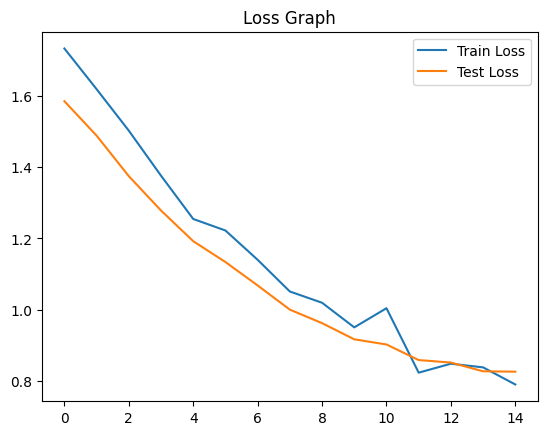

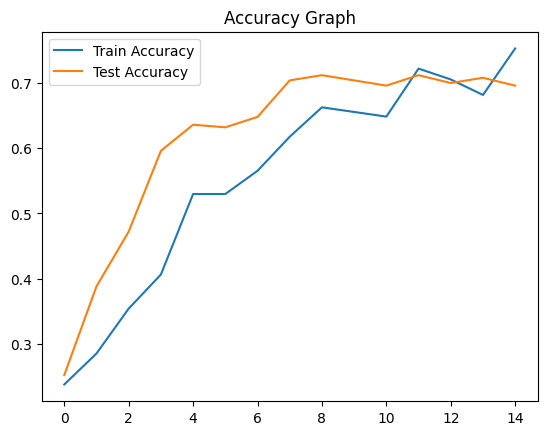

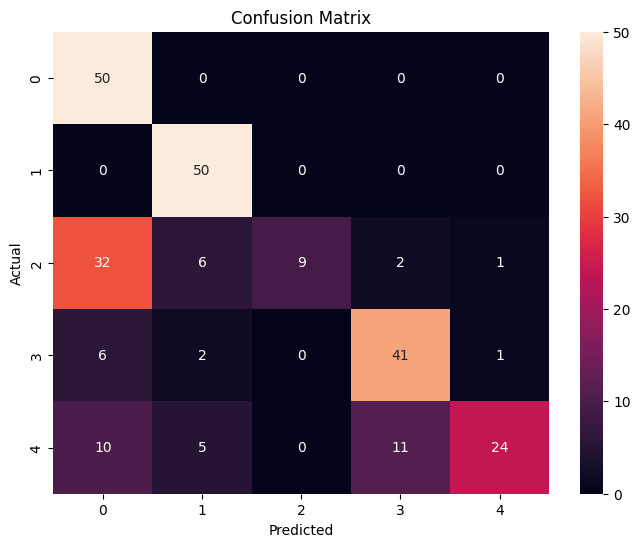

In [ ]:
# ==========================
# ALL IN ONE CELL
# ==========================

import os
import time
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# --------------------------
# SETTINGS
# --------------------------

best_acc = 0.0
epochs = 15

save_dir = "/content/drive/MyDrive/5cat_waste_data/"
os.makedirs(save_dir, exist_ok=True)

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

# --------------------------
# CHECK DATASET
# --------------------------

print("Train Dataset size:", len(train_dataset))
print("Test Dataset size:", len(test_dataset))

print("Train Loader batches:", len(train_loader))
print("Test Loader batches:", len(test_loader))


# Inspect first batch

imgs, labels = next(iter(train_loader))

print("Batch shape:", imgs.shape)
print("Labels shape:", labels.shape)

print("Min label:", labels.min().item())
print("Max label:", labels.max().item())

print("Unique labels:", torch.unique(labels))


# --------------------------
# TRAIN FUNCTION
# --------------------------

def train_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs,1)

        correct += (preds==labels).sum().item()

        total += labels.size(0)


    avg_loss = total_loss / len(loader)

    acc = correct/total

    return avg_loss,acc


# --------------------------
# EVAL FUNCTION
# --------------------------

def eval_epoch(model, loader):

    model.eval()

    total_loss = 0

    all_preds=[]
    all_labels=[]

    with torch.no_grad():

        for images,labels in loader:

            images=images.to(device)
            labels=labels.to(device)

            outputs=model(images)

            loss=criterion(outputs,labels)

            total_loss+=loss.item()

            preds=torch.argmax(outputs,1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    avg_loss=total_loss/len(loader)

    acc=accuracy_score(all_labels,all_preds)

    precision=precision_score(all_labels,all_preds,average='weighted')

    recall=recall_score(all_labels,all_preds,average='weighted')

    f1=f1_score(all_labels,all_preds,average='weighted')

    cm=confusion_matrix(all_labels,all_preds)

    return avg_loss,acc,precision,recall,f1,cm,all_labels,all_preds


# --------------------------
# TRAIN LOOP
# --------------------------

for epoch in range(epochs):

    t0=time.time()

    train_loss,train_acc=train_epoch(model,train_loader)

    test_loss,test_acc,precision,recall,f1,cm,y_true,y_pred=eval_epoch(model,test_loader)


    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)


    print("\n====================")

    print("Epoch",epoch+1,"/",epochs)

    print("\nTrain")

    print("Loss:",train_loss)
    print("Accuracy:",train_acc)


    print("\nTest")

    print("Loss:",test_loss)
    print("Accuracy:",test_acc)

    print("Precision:",precision)
    print("Recall:",recall)
    print("F1:",f1)


    print("\nClassification Report")

    print(classification_report(y_true,y_pred))


    if test_acc>best_acc:

        best_acc=test_acc

        torch.save(
            model.state_dict(),
            os.path.join(save_dir,
            "mobilenet_best.pth")
        )

        print("\nSaved Best Model")


    print("Time:",time.time()-t0)



# --------------------------
# PLOTS
# --------------------------

print("\nTraining Finished")


# Loss graph

plt.figure()

plt.plot(train_losses,label="Train Loss")
plt.plot(test_losses,label="Test Loss")

plt.legend()

plt.title("Loss Graph")

plt.show()



# Accuracy graph

plt.figure()

plt.plot(train_accuracies,label="Train Accuracy")
plt.plot(test_accuracies,label="Test Accuracy")

plt.legend()

plt.title("Accuracy Graph")

plt.show()



# Confusion Matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
import torch
from torchvision import models
import torch.nn as nn

num_classes = 4  # change to your actual number of classes

# The 'model' object is already correctly initialized in previous cells
# using the 'get_model' function, which sets its classifier architecture.
# Redefining the classifier here would create an architectural mismatch
# with the saved state_dict.
# Therefore, the lines that redefine the classifier have been removed.

# Step 2: Load saved weights
state_dict_path = "/content/drive/MyDrive/5cat_waste_data/mobilenet_best.pth"
model.load_state_dict(torch.load(state_dict_path, map_location="cpu"))
# Step 3: Switch to evaluation mode
model.eval()

torch.save(model, "/content/drive/MyDrive/5cat_waste_data/mobilenet_best.pth")

In [ ]:
# import torch
# from torchvision import models
# import torch.nn as nn

# num_classes = 5  # Corrected to 5 classes based on your dataset

# # Step 1: Load the full model object directly
# state_dict_path = "/content/drive/MyDrive/waste_models/newwwww_manual_waste_new_mobilenetv2_best.pth"
# model = torch.load(state_dict_path, map_location=device, weights_only=False)

# # Step 2: Ensure the model is on the correct device
# model = model.to(device)

# # Step 3: Switch to evaluation mode
# model.eval()

# torch.save(model, "/content/drive/MyDrive/waste_models/manual_newer_waste_new_mobilenetv2_best.pth")

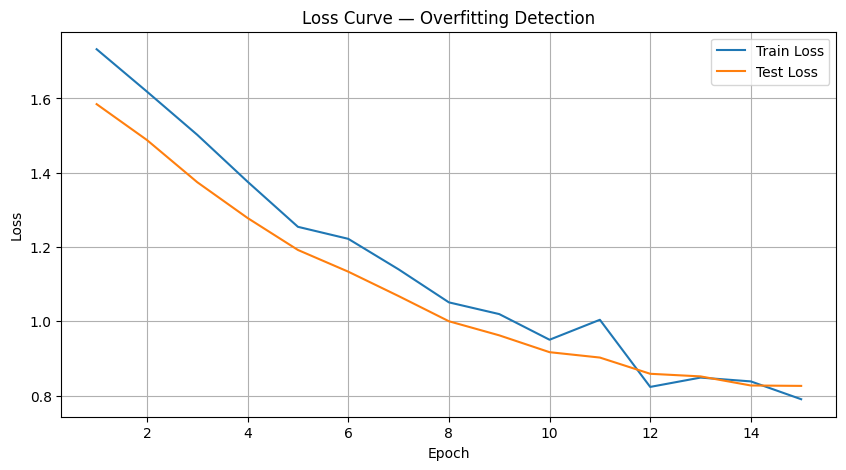

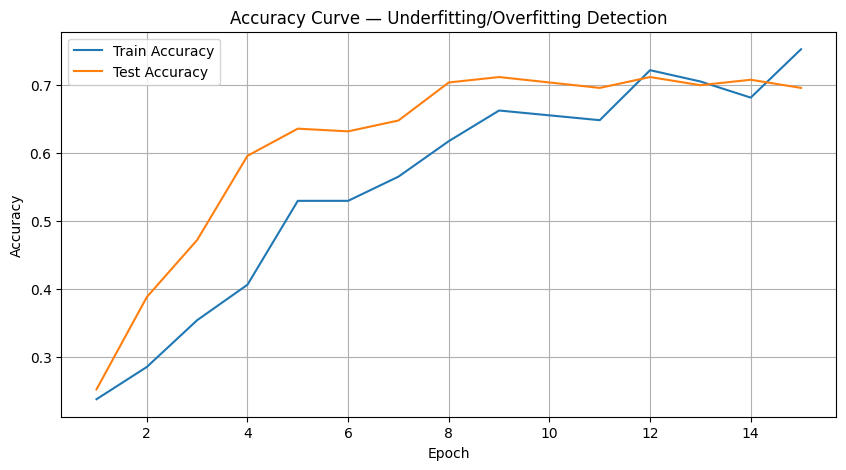

In [ ]:
import matplotlib.pyplot as plt

# Adjust epochs_range to match the actual number of completed epochs
epochs_completed = len(train_losses)
epochs_range = range(1, epochs_completed + 1)

# ---- LOSS GRAPH ----
plt.figure(figsize=(10,5))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve — Overfitting Detection")
plt.legend()
plt.grid(True)
plt.show()

# ---- ACCURACY GRAPH ----
plt.figure(figsize=(10,5))
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve — Underfitting/Overfitting Detection")
plt.legend()
plt.grid(True)
plt.show()

📊 Evaluation Metrics
Accuracy:  0.7120
Precision: 0.7853
Recall:    0.7120
F1-score:  0.6717

Detailed classification report:
              precision    recall  f1-score   support

       metal       0.59      1.00      0.74        50
        none       0.82      1.00      0.90        50
     organic       1.00      0.22      0.36        50
       paper       0.67      0.88      0.76        50
     plastic       0.85      0.46      0.60        50

    accuracy                           0.71       250
   macro avg       0.79      0.71      0.67       250
weighted avg       0.79      0.71      0.67       250



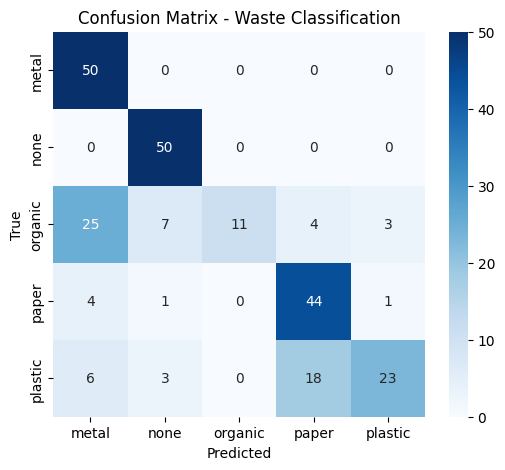

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ----------------------------
# Load best saved model
# ----------------------------
# The file "newer_waste_new_mobilenetv2_best.pth" was saved using `torch.save(model, ...)` in the previous cell,
# which saves the entire model object. To correctly load it, we should assign the output of `torch.load` directly
# to the 'model' variable, and set `weights_only=False` to allow loading of the full model object.
model = torch.load("/content/drive/MyDrive/5cat_waste_data/mobilenet_best.pth", map_location=device, weights_only=False)
model.eval() # Ensure the model is in evaluation mode

# ----------------------------
# Evaluate on Test Set
# ----------------------------
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())

# ----------------------------
# Metrics
# ----------------------------
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("📊 Evaluation Metrics")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nDetailed classification report:")
class_names = test_dataset.classes
print(classification_report(y_true, y_pred, target_names=class_names))

# ----------------------------
# Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Waste Classification")
plt.show()